# Blind Frame Recognition (Modular Implementation)

This notebook implements blind frame recognition based on:

1. Correlation-based frame length estimation
2. Periodic averaging for synchronization word recovery

The implementation is fully modular and allows experimentation with:

- Frame length (N)
- Sync word length (L)
- Window size
- SNR
- Number of frames
- Timing offset

The signal model follows BPSK modulation with AWGN.


## 1. Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

np.random.seed(42)


## 2. Synthetic Signal Generator

Signal Model:

r[n] = s[n] + w[n]

Each frame:
[ Sync Word | Random Data ]

BPSK modulation:
0 → +1
1 → -1


In [2]:
def generate_sync_word(sw_len, fixed=True):
    """
    Generate binary sync word.
    If fixed=True, seed is fixed (same SW every run).
    """
    if fixed:
        rng = np.random.default_rng(123)
        bits = rng.integers(0, 2, sw_len)
    else:
        bits = np.random.randint(0, 2, sw_len)
        
    return bits


In [3]:
def build_frames(num_frames, frame_len, sw_bits):
    """
    Build frames: [SW | random data]
    """
    sw_len = len(sw_bits)
    data_len = frame_len - sw_len
    
    all_bits = []
    
    for _ in range(num_frames):
        data_bits = np.random.randint(0, 2, data_len)
        frame = np.concatenate([sw_bits, data_bits])
        all_bits.append(frame)
        
    return np.concatenate(all_bits)


In [4]:
def bpsk_modulation(bits):
    """
    0 → +1
    1 → -1
    """
    return 1 - 2 * bits


In [5]:
def apply_offset(signal, offset):
    return np.roll(signal, offset)


In [6]:
def add_awgn(signal, snr_db):
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10)
    noise_power = signal_power / snr_linear
    
    noise = np.sqrt(noise_power) * np.random.randn(len(signal))
    return signal + noise


In [7]:
def generate_signal(
    frame_len=256,
    sw_len=32,
    num_frames=200,
    snr_db=10,
    offset=0
):
    sw_bits = generate_sync_word(sw_len)
    bits = build_frames(num_frames, frame_len, sw_bits)
    signal = bpsk_modulation(bits)
    signal = apply_offset(signal, offset)
    received = add_awgn(signal, snr_db)
    
    return received, frame_len, sw_len


## 3. Correlation-Based Estimation


In [8]:
def sliding_correlation(r, tau_max, window_size=None):
    N = len(r)
    
    if window_size is None:
        window_size = N - tau_max
        
    C = []
    
    for tau in range(1, tau_max):
        max_valid = min(window_size, N - tau)
        if max_valid <= 0:
            C.append(0)
            continue
        
        x1 = r[:max_valid]
        x2 = r[tau:tau+max_valid]
        
        numerator = np.sum(x1 * x2)
        denominator = np.sqrt(np.sum(x1**2) * np.sum(x2**2))
        
        C.append(numerator / denominator)
        
    return np.array(C)


In [9]:
def estimate_frame_length(C, min_distance=20):
    peaks, _ = find_peaks(C, distance=min_distance)
    
    if len(peaks) < 2:
        return None
    
    diffs = np.diff(peaks)
    return int(np.median(diffs))


## 4. Periodic Averaging


In [10]:
def estimate_offset(C):
    return np.argmax(C)


In [11]:
def periodic_average(r, frame_len, offset):
    K = (len(r) - offset) // frame_len
    avg = np.zeros(frame_len)
    
    for k in range(K):
        start = offset + k * frame_len
        avg += r[start:start+frame_len]
        
    return avg / K


## 5. Single Experiment Runner


In [12]:
def run_experiment(
    frame_len=256,
    sw_len=32,
    num_frames=200,
    snr_db=10,
    offset=0,
    tau_max=600,
    window_size=2000
):
    
    r, true_frame_len, _ = generate_signal(
        frame_len, sw_len, num_frames, snr_db, offset
    )
    
    C = sliding_correlation(r, tau_max, window_size)
    L_est = estimate_frame_length(C)
    
    return r, C, L_est


## 6. Example Run


Estimated Frame Length: 25


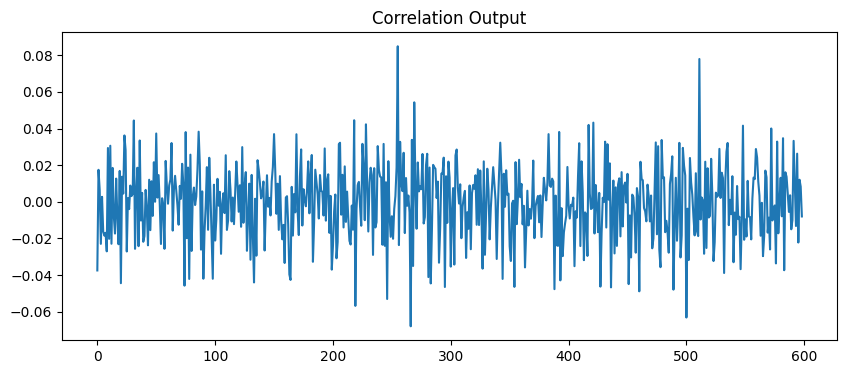

In [13]:
r, C, L_est = run_experiment(
    frame_len=256,
    sw_len=32,
    num_frames=300,
    snr_db=5,
    offset=100,
    tau_max=600,
    window_size=3000
)

print("Estimated Frame Length:", L_est)

plt.figure(figsize=(10,4))
plt.plot(C)
plt.title("Correlation Output")
plt.show()


## 7. Parameter Sensitivity Analysis


In [14]:
frame_lengths = [128, 256, 384, 512]
results = []

for N in frame_lengths:
    r, C, L_est = run_experiment(
        frame_len=N,
        sw_len=32,
        num_frames=300,
        snr_db=5,
        offset=50,
        tau_max=1200,
        window_size=4000
    )
    results.append(L_est)

print("Frame Length vs Estimated Frame Length:")
print(list(zip(frame_lengths, results)))


Frame Length vs Estimated Frame Length:
[(128, 27), (256, 28), (384, 24), (512, 25)]


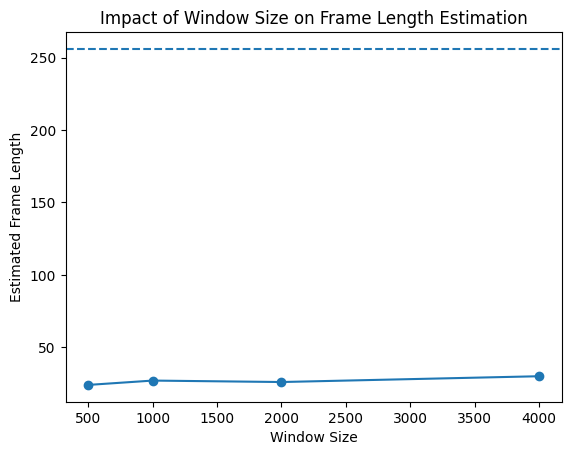

In [16]:
import matplotlib.pyplot as plt
import numpy as np

window_sizes = [500, 1000, 2000, 4000]
results_ws = []

for ws in window_sizes:
    r, C, L_est = run_experiment(
        frame_len=256,
        sw_len=32,
        num_frames=300,
        snr_db=5,
        offset=50,
        tau_max=600,
        window_size=ws
    )
    results_ws.append(L_est)

# Convert to numpy arrays
window_sizes = np.array(window_sizes)
results_ws = np.array(results_ws)

plt.figure()
plt.plot(window_sizes, results_ws, marker='o')
plt.axhline(y=256, linestyle='--')  # true frame length
plt.xlabel("Window Size")
plt.ylabel("Estimated Frame Length")
plt.title("Impact of Window Size on Frame Length Estimation")
plt.show()


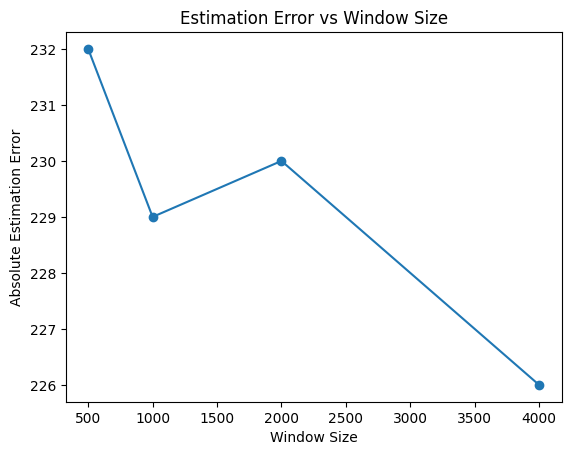

In [17]:
true_L = 256
errors = np.abs(true_L - results_ws)

plt.figure()
plt.plot(window_sizes, errors, marker='o')
plt.xlabel("Window Size")
plt.ylabel("Absolute Estimation Error")
plt.title("Estimation Error vs Window Size")
plt.show()


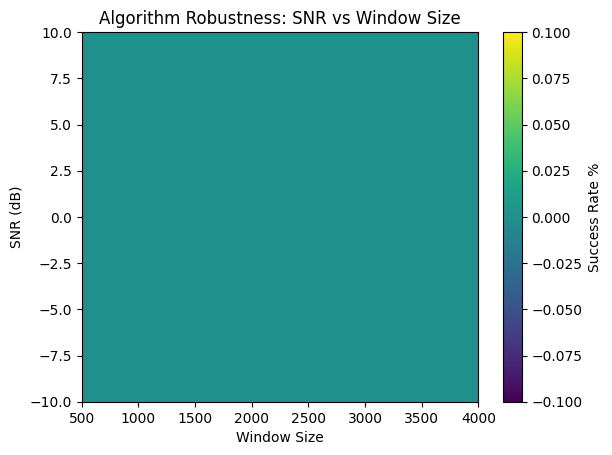

In [19]:
snr_range = np.linspace(-10, 10, 5)
ws_range = [500, 1000, 2000, 4000]
success_matrix = np.zeros((len(snr_range), len(ws_range)))

for i, snr in enumerate(snr_range):
    for j, ws in enumerate(ws_range):
        # Run 10 trials per setting to get a percentage
        success_count = 0
        for _ in range(10):
            _, _, L_est = run_experiment(frame_len=256, snr_db=snr, window_size=ws)
            if L_est == 256: success_count += 1
        success_matrix[i, j] = (success_count / 10) * 100

# Plotting the Heatmap
plt.imshow(success_matrix, extent=[500, 4000, -10, 10], origin='lower', aspect='auto')
plt.colorbar(label='Success Rate %')
plt.xlabel('Window Size')
plt.ylabel('SNR (dB)')
plt.title('Algorithm Robustness: SNR vs Window Size')
plt.show()